#### Import Libraries

In [3]:
import csv
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


#### Locate and Load the Groceries Dataset

In [4]:
data_file = Path("groceries.csv")

if not data_file.exists():
    raise FileNotFoundError(
        "groceries.csv was not found"
    )

transactions = []

with open(data_file, newline="", encoding="utf-8") as f:
    reader = csv.reader(f)

    for row in reader:
        items = [item.strip() for item in row if item.strip() != ""]

        if items:
            transactions.append(items)
print("Number of transactions:", len(transactions))


Number of transactions: 9835


In [5]:
n_transactions = len(transactions)

# Find all unique items
all_items = sorted(set(item for transaction in transactions for item in transaction))
n_items = len(all_items)

print("Number of transactions:", n_transactions)
print("Number of unique items:", n_items)


Number of transactions: 9835
Number of unique items: 169


#### The Top 10 Most Frequently Purchased Items

In [6]:
item_counts = Counter(
    item
    for transaction in transactions
    for item in transaction
)

top10 = item_counts.most_common(10)

print("Top 10 items:\n")

for item, count in top10:
    support = count / n_transactions
    print(f"{item}: {count} ({support:.3f})")


Top 10 items:

whole milk: 2513 (0.256)
other vegetables: 1903 (0.193)
rolls/buns: 1809 (0.184)
soda: 1715 (0.174)
yogurt: 1372 (0.140)
bottled water: 1087 (0.111)
root vegetables: 1072 (0.109)
tropical fruit: 1032 (0.105)
shopping bags: 969 (0.099)
sausage: 924 (0.094)


#### Convert Transactions into One-Hot Encoded Data

Apriori requires the transaction data to be represented in a **one-hot encoded** format.
- `True` means the item is in the transaction `False` means the item does not appear

In [7]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("One-hot encoded dataset shape:", df.shape)

df.head()


One-hot encoded dataset shape: (9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### Generate Frequent Itemsets with Apriori

Here we use a minimum support of **0.01 (1%)**.


In [8]:
MIN_SUPPORT = 0.01

freq_itemsets = apriori(
    df,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

# Add the number of items in each itemset
freq_itemsets["length"] = freq_itemsets["itemsets"].apply(len)

# Sort by support
freq_itemsets = freq_itemsets.sort_values(
    "support",
    ascending=False
).reset_index(drop=True)

multi_itemsets = freq_itemsets[
    freq_itemsets["length"] >= 2
].sort_values(
    "support",
    ascending=False
)

print("Total frequent itemsets:", len(freq_itemsets))
print("Frequent itemsets containing 2 or more items:", len(multi_itemsets))


Total frequent itemsets: 333
Frequent itemsets containing 2 or more items: 245


#### Top 15 Multi-Item Frequent Itemsets

In [10]:
multi_itemsets.head(5)


,support,itemsets,length
16,0.074835,"(other vegetables, whole milk)",2
25,0.056634,"(rolls/buns, whole milk)",2
26,0.056024,"(yogurt, whole milk)",2
32,0.048907,"(root vegetables, whole milk)",2
34,0.047382,"(root vegetables, other vegetables)",2


### Save Frequent Itemsets

In [11]:
frequent_itemsets_file = Path("frequent_itemsets.csv")

multi_itemsets.head(20).to_csv(
    frequent_itemsets_file,
    index=False
)

print(f"Saved: {frequent_itemsets_file.resolve()}")


Saved: /Users/irakizajimmy/MS BIG DATA/Data Mining/AssociationRule/frequent_itemsets.csv


#### Generate Association Rules

Association rules help us identify relationships between items.

We use:
- **Support** — how frequently the complete rule occurs.
- **Confidence** — how often the consequent occurs when the antecedent occurs.
- **Lift** — how much more often the items occur together compared with what would be expected if they were independent.

Here, the minimum confidence is **0.30 (30%)**.

In [12]:
MIN_CONFIDENCE = 0.30

rules = association_rules(
    freq_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

rules = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

rules = rules.sort_values(
    "lift",
    ascending=False
).reset_index(drop=True)

print("Total rules generated:", len(rules))


Total rules generated: 125


#### Format the Association Rules for Easy Reading

In [14]:
def format_itemset(itemset):
    return ", ".join(sorted(itemset))

rules_display = rules.copy()

rules_display["antecedents"] = rules_display["antecedents"].apply(
    format_itemset
)

rules_display["consequents"] = rules_display["consequents"].apply(
    format_itemset
)

rules_display.head(5)


,antecedents,consequents,support,confidence,lift
0,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
1,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780
2,beef,root vegetables,0.017387,0.331395,3.040367
3,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
4,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999


#### Top 15 Association Rules by Lift

In [16]:
rules_display.head(5)


,antecedents,consequents,support,confidence,lift
0,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
1,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780
2,beef,root vegetables,0.017387,0.331395,3.040367
3,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
4,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999


In [17]:
# Highest Confidence Rules
rules_display.sort_values(
    "confidence",
    ascending=False
).head(5)


,antecedents,consequents,support,confidence,lift
3,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
4,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999
22,"curd, yogurt",whole milk,0.010066,0.582353,2.279125
24,"butter, other vegetables",whole milk,0.011490,0.573604,2.244885
26,"root vegetables, tropical fruit",whole milk,0.011998,0.570048,2.230969


In [18]:
# Highest Support Rules
rules_display.sort_values(
    "support",
    ascending=False
).head(5)


,antecedents,consequents,support,confidence,lift
106,other vegetables,whole milk,0.074835,0.386758,1.513634
124,rolls/buns,whole milk,0.056634,0.307905,1.205032
101,yogurt,whole milk,0.056024,0.401603,1.571735
71,root vegetables,whole milk,0.048907,0.448694,1.756031
23,root vegetables,other vegetables,0.047382,0.434701,2.246605


In [19]:
# Highest Lift Rules
rules_display.sort_values(
    "lift",
    ascending=False
).head(5)


,antecedents,consequents,support,confidence,lift
0,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
1,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780
2,beef,root vegetables,0.017387,0.331395,3.040367
3,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
4,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999


#### Saving Association Rules

In [20]:
rules_file = Path("association_rules.csv")

rules_display.to_csv(
    rules_file,
    index=False
)

print(f"Saved: {rules_file.resolve()}")


Saved: /Users/irakizajimmy/MS BIG DATA/Data Mining/AssociationRule/association_rules.csv


#### Visualization: Top 10 Most Frequently Purchased Items

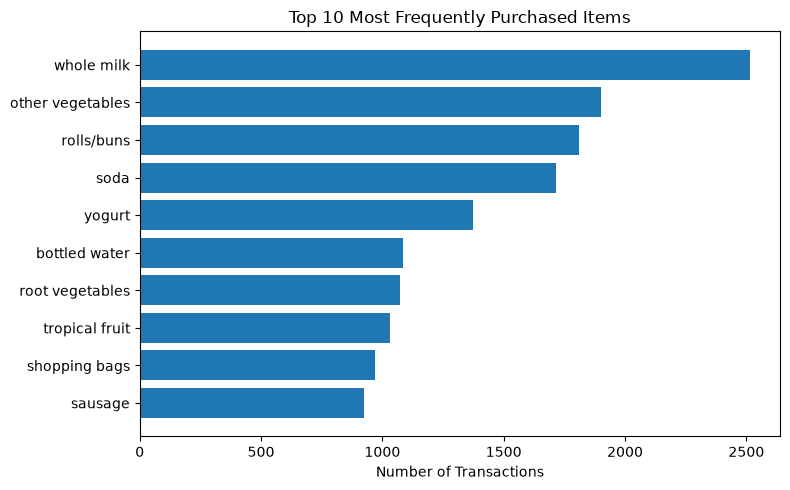

In [21]:
# Prepare data for the chart
items = [item for item, count in top10]
counts = [count for item, count in top10]

plt.figure(figsize=(8, 5))

plt.barh(
    items[::-1],
    counts[::-1]
)

plt.xlabel("Number of Transactions")
plt.title("Top 10 Most Frequently Purchased Items")

plt.tight_layout()

plt.savefig(
    "top10_items.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


#### Visualization: Top 10 Association Rules by Lift

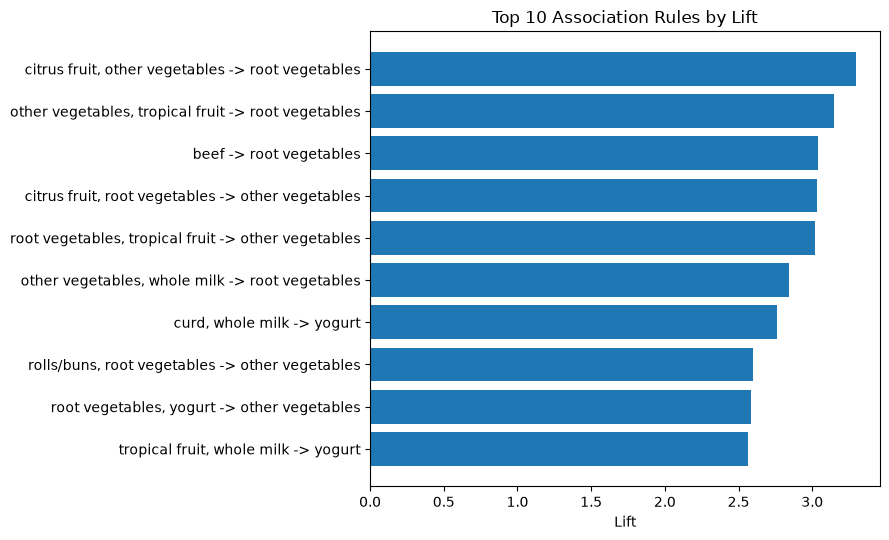

In [22]:
top_lift = rules_display.sort_values(
    "lift",
    ascending=False
).head(10).copy()

top_lift["rule"] = (
    top_lift["antecedents"]
    + " -> "
    + top_lift["consequents"]
)

plt.figure(figsize=(9, 5.5))

plt.barh(
    top_lift["rule"][::-1],
    top_lift["lift"][::-1]
)

plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift")

plt.tight_layout()

plt.savefig(
    "top10_rules_lift.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


The analysis involved loading and exploring the grocery transaction dataset, identifying the most frequently purchased items, and transforming the transactions into a one-hot encoded format. The Apriori algorithm was then used to generate frequent itemsets, followed by the generation of association rules using a minimum confidence of 30%. The resulting rules were evaluated based on support, confidence, and lift, with the frequent itemsets and association rules saved as CSV files for further analysis. Finally, two charts were created to visualize the most frequently purchased items and the top association rules based on lift.